In [15]:
import pandas as pd

In [16]:
df = pd.read_csv("train.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
print(df.shape)

(159571, 8)


In [5]:
print(df.columns)

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')


In [6]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [7]:
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [8]:
df[['toxic','severe_toxic','obscene','threat','insult','identity_hate']].sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

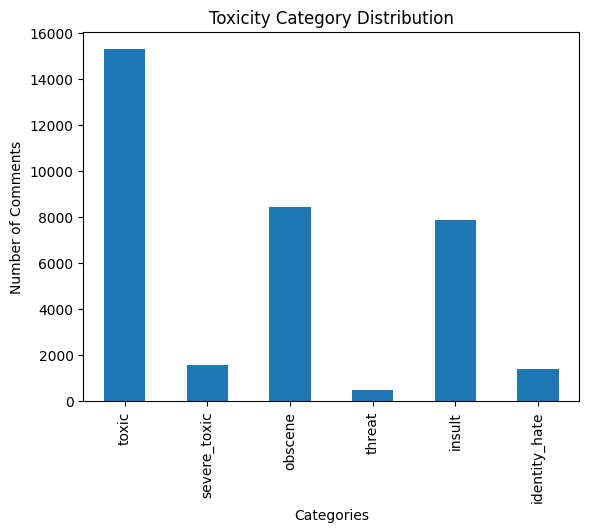

In [9]:
import matplotlib.pyplot as plt

toxicity_counts = df[['toxic','severe_toxic','obscene','threat','insult','identity_hate']].sum()

toxicity_counts.plot(kind='bar')

plt.title("Toxicity Category Distribution")
plt.xlabel("Categories")
plt.ylabel("Number of Comments")

plt.show()

In [10]:
print((df['toxic'].sum() / len(df)) * 100)

9.584448302009765


In [11]:
df[df['toxic'] == 1]['comment_text'].iloc[0]

'COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK'

In [12]:
df[df['toxic'] == 1]['comment_text'].head(5)

6          COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK
12    Hey... what is it..\n@ | talk .\nWhat is it......
16    Bye! \n\nDon't look, come or think of comming ...
42    You are gay or antisemmitian? \n\nArchangel WH...
43             FUCK YOUR FILTHY MOTHER IN THE ASS, DRY!
Name: comment_text, dtype: object

In [4]:
import re

def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r'\n', ' ', text)  # remove line breaks
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # keep only letters and spaces
    return text

In [14]:
sample_text = df[df['toxic'] == 1]['comment_text'].iloc[0]

print("Original Text:")
print(sample_text)

print("\nCleaned Text:")
print(clean_text(sample_text))

Original Text:
COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK

Cleaned Text:
cocksucker before you piss around on my work


In [17]:
df['clean_comment'] = df['comment_text'].apply(clean_text)

In [16]:
df[['comment_text', 'clean_comment']].head()

,comment_text,clean_comment
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,daww he matches this background colour im seem...
2,"Hey man, I'm really not trying to edit war. It...",hey man im really not trying to edit war its j...
3,"""\nMore\nI can't make any real suggestions on ...",more i cant make any real suggestions on impr...
4,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...


In [18]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [18]:
tokenizer = Tokenizer(num_words=20000)

tokenizer.fit_on_texts(df['clean_comment'])

In [21]:
print(list(tokenizer.word_index.items())[:20])

[('the', 1), ('to', 2), ('of', 3), ('and', 4), ('a', 5), ('you', 6), ('i', 7), ('is', 8), ('that', 9), ('in', 10), ('it', 11), ('for', 12), ('this', 13), ('not', 14), ('on', 15), ('be', 16), ('as', 17), ('have', 18), ('are', 19), ('your', 20)]


In [22]:
sequences = tokenizer.texts_to_sequences(df['clean_comment'])

In [23]:
print("Original Comment:")
print(df['clean_comment'].iloc[0])

print("\nSequence:")
print(sequences[0])

Original Comment:
explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the template from the talk page since im retired now

Sequence:
[638, 75, 1, 122, 126, 173, 28, 627, 4526, 11337, 1050, 82, 311, 52, 2007, 10787, 50, 6450, 15, 61, 2607, 143, 7, 2760, 33, 114, 1131, 15148, 2792, 4, 45, 54, 234, 1, 409, 30, 1, 43, 27, 141, 69, 3341, 89]


In [5]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [25]:
X = pad_sequences(sequences, maxlen=100)

print(X.shape)

(159571, 100)


In [26]:
y = df[['toxic',
        'severe_toxic',
        'obscene',
        'threat',
        'insult',
        'identity_hate']]

print(y.shape)

(159571, 6)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(127656, 100)
(31915, 100)


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [29]:
model = Sequential()

model.add(Embedding(input_dim=20000, output_dim=128, input_length=100))

model.add(LSTM(64))

model.add(Dropout(0.3))

model.add(Dense(6, activation='sigmoid'))

c:\Users\Boya_\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [30]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = model.fit(
    X_train,
    y_train,
    epochs=2,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/2
798/798 ━━━━━━━━━━━━━━━━━━━━ 89s 108ms/step - accuracy: 0.8190 - loss: 0.0932 - val_accuracy: 0.9943 - val_loss: 0.0542
Epoch 2/2
798/798 ━━━━━━━━━━━━━━━━━━━━ 87s 108ms/step - accuracy: 0.9464 - loss: 0.0504 - val_accuracy: 0.9943 - val_loss: 0.0512


In [33]:
y_pred = model.predict(X_test)

998/998 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step


In [34]:
y_pred_binary = (y_pred > 0.5).astype(int)

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_binary))

              precision    recall  f1-score   support

           0       0.88      0.71      0.79      3056
           1       0.71      0.11      0.19       321
           2       0.83      0.74      0.78      1715
           3       0.00      0.00      0.00        74
           4       0.75      0.61      0.67      1614
           5       0.00      0.00      0.00       294

   micro avg       0.83      0.63      0.72      7074
   macro avg       0.53      0.36      0.41      7074
weighted avg       0.78      0.63      0.69      7074
 samples avg       0.06      0.06      0.06      7074



c:\Users\Boya_\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Boya_\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Boya_\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [36]:
model.save("toxcity_detection_model.h5")

print("Model Saved Successfully!")

Model Saved Successfully!


In [2]:
def predict_toxicity(text):
    
    text = clean_text(text)
    
    sequence = tokenizer.texts_to_sequences([text])
    
    padded = pad_sequences(sequence, maxlen=100)
    
    prediction = model.predict(padded, verbose=0)[0]
    
    labels = [
        'toxic',
        'severe_toxic',
        'obscene',
        'threat',
        'insult',
        'identity_hate'
    ]
    
    for label, score in zip(labels, prediction):
        print(f"{label}: {score:.4f}")  

       

In [19]:
from tensorflow.keras.models import load_model

model = load_model("toxcity_detection_model.h5")

In [20]:
def predict_toxicity(text):
    
    text = clean_text(text)
    
    sequence = tokenizer.texts_to_sequences([text])
    
    padded = pad_sequences(sequence, maxlen=100)
    
    prediction = model.predict(padded, verbose=0)[0]
    
    labels = [
        'toxic',
        'severe_toxic',
        'obscene',
        'threat',
        'insult',
        'identity_hate'
    ]
    
    for label, score in zip(labels, prediction):
        print(f"{label}: {score:.4f}")

In [21]:
predict_toxicity("You are a stupid idiot")

toxic: 0.9718
severe_toxic: 0.1870
obscene: 0.8902
threat: 0.0322
insult: 0.8027
identity_hate: 0.1133


In [22]:
import pickle

with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer Saved Successfully!")

Tokenizer Saved Successfully!
